# 6.1 What changed and what only looks like change?

**Question:** Can we separate an injected vegetation-like change from cloud contamination, seasonal variation and misalignment?

**Objectives:** compare two raster dates on the same grid; compute NDVI differences; retain an explicit valid-data mask; evaluate a transparent threshold baseline; explain false positives and unsupported causal claims.

**Prerequisites:** Python arrays, plotting, and lesson 1.1; lesson 2.1 is helpful. **Time:** 75–90 minutes. **Setup:** existing `requirements.txt`; no credentials, downloads or GPU.

**Data:** entirely synthetic red/NIR reflectance-like arrays on an invented 30 m grid. These are not satellite acquisitions, mapped damage or measurements of Colorado. They let us know which changes were injected. The real satellite extension at the end is a separate, guided activity.

**Remember:** predict - run - explain - change one thing. This is a change-detection baseline worth understanding before introducing a learned model.

## Before you run

NDVI = (near infrared - red) / (near infrared + red). We compute **after minus before**; a negative difference means lower NDVI in the second image. See [USGS NDVI documentation](https://www.usgs.gov/landsat-missions/landsat-normalized-difference-vegetation-index).

Predict: will a cloud-like patch create a false change? Will a seasonal shift affect only our injected change region? Write your predictions before running.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import display
from rasterio.transform import from_origin

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'course.py').exists())
OUT = ROOT/'data'/'generated'/'change_detection'
OUT.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(42)
height, width = 120, 160
y, x = np.mgrid[:height, :width]
vegetated = (x > 24) & (x < 135) & (y > 12) & (y < 108)
red_before = np.where(vegetated, 0.12, 0.24) + rng.normal(0, 0.004, (height, width))
nir_before = np.where(vegetated, 0.55, 0.30) + rng.normal(0, 0.004, (height, width))
truth = (x > 65) & (x < 115) & (y > 45) & (y < 90)
red_after = red_before + rng.normal(0, 0.008, (height, width))
nir_after = nir_before + rng.normal(0, 0.012, (height, width))
red_after[truth] += 0.09
nir_after[truth] -= 0.16
cloud = (x > 30) & (x < 76) & (y > 22) & (y < 54)
red_after[cloud], nir_after[cloud] = 0.65, 0.68
# Both dates have invalid border pixels. Do not replace nodata with zero.
red_before[:3], nir_before[:3] = np.nan, np.nan
red_after[:3], nir_after[:3] = np.nan, np.nan
meta_before = dict(crs='EPSG:32613', transform=from_origin(475000, 4430000, 30, 30),
                   shape=(height, width))
meta_after = meta_before.copy()
print('Synthetic fixture:', height * width, 'pixels; 30 m grid; seed 42')

Synthetic fixture: 19200 pixels; 30 m grid; seed 42


## Check geometry before subtracting

Matching array shapes do not imply matching ground locations. Check CRS, affine transform and dimensions. These metadata checks are necessary, but real imagery also needs visual registration checks. Reprojection cannot remove every sensor or registration error.

When alignment is needed, choose a common target grid. Interpolate continuous reflectance deliberately; use nearest-neighbor resampling for categorical masks. See [Rasterio reprojection](https://rasterio.readthedocs.io/en/stable/topics/reproject.html) and [resampling](https://rasterio.readthedocs.io/en/stable/topics/resampling.html).

In [2]:
def require_same_grid(left, right):
    for key in ['crs', 'transform', 'shape']:
        if left[key] != right[key]:
            raise ValueError(f'Grid mismatch: {key}; align before comparing.')

require_same_grid(meta_before, meta_after)
shifted_meta = {**meta_after, 'transform': from_origin(475030, 4430000, 30, 30)}
try:
    require_same_grid(meta_before, shifted_meta)
except ValueError as exc:
    print('Expected teaching failure:', exc)
else:
    raise AssertionError('A shifted grid should be rejected.')

def ndvi(red, nir):
    denominator = nir + red
    result = np.full(red.shape, np.nan, dtype=float)
    valid = np.isfinite(red) & np.isfinite(nir) & (np.abs(denominator) > 1e-8)
    np.divide(nir - red, denominator, out=result, where=valid)
    return result

before = ndvi(red_before, nir_before)
after = ndvi(red_after, nir_after)
delta = after - before
finite = np.isfinite(before) & np.isfinite(after)
# Perfect cloud knowledge is available only because we built the fixture.
valid = finite & ~cloud
assert np.isnan(ndvi(np.zeros((1, 1)), np.zeros((1, 1)))[0, 0])
assert not valid[:3].any()
print(f'Observable coverage: {valid.mean():.1%}; excluded pixels: {(~valid).sum()}')

Expected teaching failure: Grid mismatch: transform; align before comparing.
Observable coverage: 90.2%; excluded pixels: 1875


## A baseline you can inspect

Flag a pixel when ΔNDVI < -0.20. This is an arbitrary teaching threshold, not a recommended environmental threshold. It is fixed before inspecting the fixture's scores. A real application needs separate calibration and evaluation data.

Compare the naive and masked versions on **the same observable pixels** to avoid changing the evaluation denominator. Separately count flags on cloud pixels. Unknown pixels stay unknown in the map; they are not evidence of no change.

In [3]:
threshold = -0.20
naive = finite & (delta < threshold)
predicted = valid & (delta < threshold)

def evaluate(prediction, target, evaluation_mask):
    p, t = prediction[evaluation_mask], target[evaluation_mask]
    tp = int(np.sum(p & t)); fp = int(np.sum(p & ~t))
    fn = int(np.sum(~p & t)); tn = int(np.sum(~p & ~t))
    return dict(tp=tp, fp=fp, fn=fn, tn=tn,
                precision=tp/(tp+fp) if tp+fp else np.nan,
                recall=tp/(tp+fn) if tp+fn else np.nan)

display(pd.DataFrame([
    dict(method='naive, observable cohort', **evaluate(naive, truth, valid)),
    dict(method='masked, same cohort', **evaluate(predicted, truth, valid))
]))
print('Naive flags on excluded cloud pixels:', int((naive & cloud).sum()))
print('Injected change hidden by cloud:', int((truth & cloud).sum()), 'pixels')
transform = meta_before['transform']
pixel_area_m2 = abs(transform.a * transform.e - transform.b * transform.d)
detected_hectares = predicted.sum() * pixel_area_m2 / 10000
print(f'Detected synthetic area on observable pixels: {detected_hectares:.2f} ha')
# Projected metre units make this fixture calculation possible. It is not exact geodesic area.
assert np.array_equal(naive[valid], predicted[valid])
assert not predicted[~valid].any()
assert evaluate(predicted, truth, valid)['tp'] > 0

,method,tp,fp,fn,tn,precision,recall
0,"naive, observable cohort",2076,0,0,15249,1.0,1.0
1,"masked, same cohort",2076,0,0,15249,1.0,1.0


Naive flags on excluded cloud pixels: 1395
Injected change hidden by cloud: 80 pixels
Detected synthetic area on observable pixels: 186.84 ha


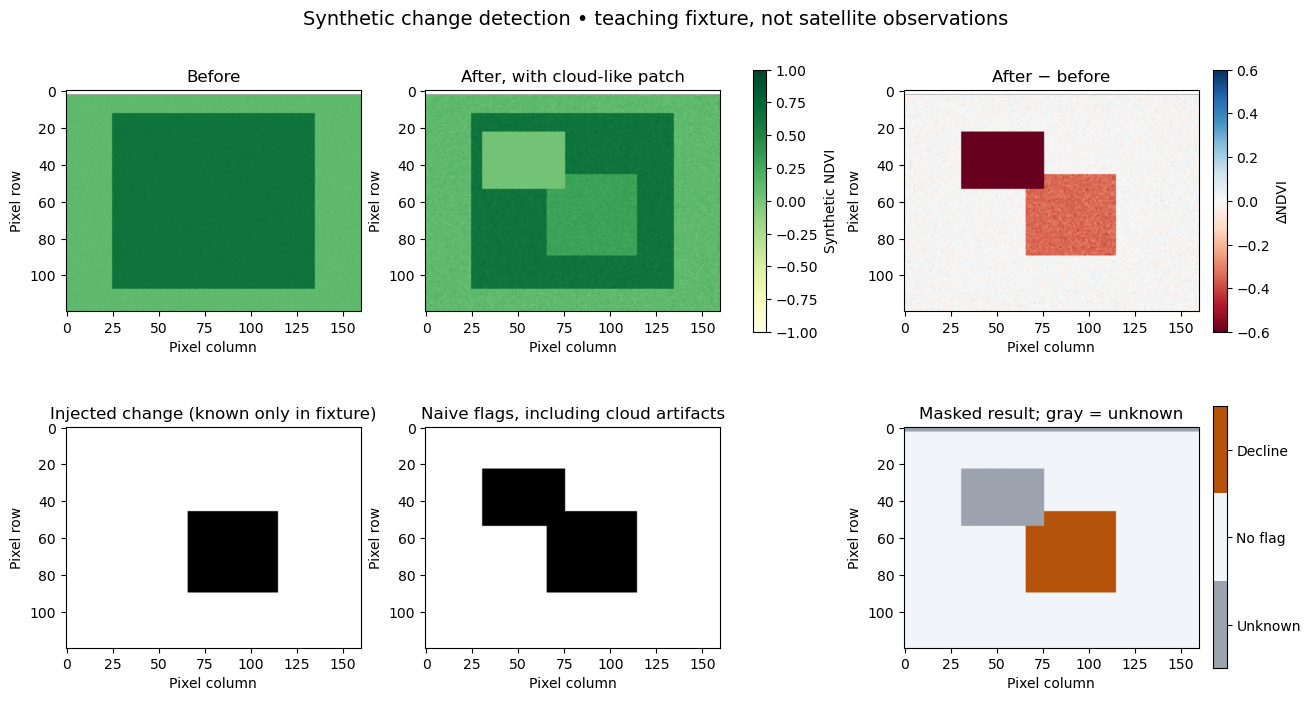

In [4]:
# Class map: unknown/no detected change/ detected decline.
classes = np.where(~valid, 0, np.where(predicted, 2, 1))
fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)
for ax, values, title in [(axes[0, 0], before, 'Before'), (axes[0, 1], after, 'After, with cloud-like patch')]:
    im = ax.imshow(values, vmin=-1, vmax=1, cmap='YlGn')
    ax.set_title(title)
fig.colorbar(im, ax=list(axes[0, :2]), label='Synthetic NDVI', shrink=0.8)
im = axes[0, 2].imshow(delta, vmin=-0.6, vmax=0.6, cmap='RdBu')
axes[0, 2].set_title('After − before')
fig.colorbar(im, ax=axes[0, 2], label='ΔNDVI', shrink=0.8)
axes[1, 0].imshow(truth, vmin=0, vmax=1, cmap='Greys')
axes[1, 0].set_title('Injected change (known only in fixture)')
axes[1, 1].imshow(naive, vmin=0, vmax=1, cmap='Greys')
axes[1, 1].set_title('Naive flags, including cloud artifacts')
im = axes[1, 2].imshow(classes, vmin=-0.5, vmax=2.5,
                      cmap=ListedColormap(['#9ca3af', '#f1f5f9', '#b45309']))
axes[1, 2].set_title('Masked result; gray = unknown')
bar = fig.colorbar(im, ax=axes[1, 2], ticks=[0, 1, 2], shrink=0.8)
bar.ax.set_yticklabels(['Unknown', 'No flag', 'Decline'])
for ax in axes.flat:
    ax.set_xlabel('Pixel column'); ax.set_ylabel('Pixel row')
fig.suptitle('Synthetic change detection • teaching fixture, not satellite observations', fontsize=14)
fig.savefig(OUT/'change_detection_preview.png', dpi=140)
plt.show()

## Challenge the apparent success

The fixture's injected signal is easy to detect; high scores do not establish real-world performance. Now introduce two competing explanations: a seasonal decline across unchanged vegetation and a one-pixel displacement of an otherwise identical image. The latter compares an image with itself after shifting, so any detected difference is an artifact.

In [5]:
seasonal_after = ndvi(red_after + 0.04, nir_after - 0.07)
seasonal_delta = seasonal_after - before
shifted = np.full_like(before, np.nan)
shifted[:, 1:] = before[:, :-1]  # No wraparound at the edge.
shift_valid = np.isfinite(before) & np.isfinite(shifted)
shift_flags = shift_valid & (np.abs(shifted - before) > abs(threshold))
print('Apparent changes from a one-pixel displacement:', int(shift_flags.sum()))
assert shift_flags.any()

rows = []
for cutoff in [-0.10, -0.20, -0.30, -0.40]:
    for name, differences in [('matched season', delta), ('seasonal confound', seasonal_delta)]:
        prediction = valid & (differences < cutoff)
        rows.append(dict(scenario=name, threshold=cutoff,
                         **evaluate(prediction, truth, valid)))
sensitivity = pd.DataFrame(rows)
display(sensitivity)
sensitivity.to_csv(OUT / 'threshold_sensitivity.csv', index=False)
# This table explores sensitivity. Do not select a winner and call it held-out performance.

Apparent changes from a one-pixel displacement: 190


,scenario,threshold,tp,fp,fn,tn,precision,recall
0,matched season,-0.1,2076,3,0,15246,0.998557,1.000000
1,seasonal confound,-0.1,2076,15069,0,180,0.121085,1.000000
2,matched season,-0.2,2076,0,0,15249,1.000000,1.000000
3,seasonal confound,-0.2,2076,5131,0,10118,0.288053,1.000000
4,matched season,-0.3,2008,0,68,15249,1.000000,0.967245
5,seasonal confound,-0.3,2076,14,0,15235,0.993301,1.000000
6,matched season,-0.4,8,0,2068,15249,1.000000,0.003854
7,seasonal confound,-0.4,2076,0,0,15249,1.000000,1.000000


## Your independent challenge

An analyst claims every brown pixel proves vegetation was destroyed. Prepare a response using your own experiment:

1. Change the cloud footprint so it hides more of the injected change. Report observable coverage and explain what cannot be concluded about hidden pixels.
2. Choose two thresholds before running. Compare false positives and false negatives on the same valid cohort, with and without the seasonal confound.
3. Make one figure with matching color scales and a distinct unknown class. Include a 100-150 word interpretation separating detection from causation.
4. Propose independent labels and a geographic/date split for evaluating a future ML change detector against this baseline.

**Submit:** figure, metric table, reproducible notebook, interpretation and evaluation design.                                          

In [6]:
# Your experiment: copy the relevant cells or add a new fixture function here.

<details><summary>Solution guidance - open after trying</summary>

Enlarge the cloud mask in the fixture and re-run from the top, including the contaminated reflectance assignment. Larger masks lower coverage; they do not establish no change under the cloud. On a fixed cohort, making the negative cutoff more extreme cannot increase the number of flagged pixels. Precision need not improve monotonically, and recall usually falls as fewer true changes are flagged. Seasonal variation can create false positives even after cloud masking. Metadata checks catch a declared grid offset; visual registration checks remain needed when metadata look correct. Independent labels should describe the change of interest, not simply repeat the NDVI threshold. Keep sites and dates used for evaluation out of model training and threshold selection.

</details>

## Check yourself and assessment

Why can two rasters with equal shapes be incompatible? Why must unknown pixels be separate from no-change pixels? Why is the threshold baseline not proof of land-cover change?

| Criterion | Points | Observable evidence |
|---|---:|---|
| Geometry and valid coverage | 2 | Catches the grid mismatch; reports exclusions and hidden change |
| Independent experiment | 3 | Changes the fixture; compares thresholds on a fixed cohort |
| Evaluation | 3 | Correct precision/recall interpretation and independent-label/split proposal |
| Communication and reproduction | 2 | Fresh run, labeled figure, synthetic-data disclosure, restrained conclusion |

**Mastery target:** 8/10, including an explicit distinction between unknown and no change. Do not reward the highest accuracy on this easy fixture.

## Transfer to actual satellite data (guided extension)

This extension requires learner-supplied imagery and is not executed or validated by the default notebook. Choose two surface-reflectance scenes for the same study area and similar seasons. Record provider URLs, acquisition dates, processing versions, band identities, scale/offset and quality-mask definitions. Decode those from the specific product documentation; do not assume raw band values are reflectance.

Load red, NIR and quality layers with Rasterio. Mask clouds, shadows, snow and nodata according to the product, apply scaling, and align both dates to one target CRS/transform/shape. Use suitable reflectance resampling and nearest-neighbor mask resampling. Inspect co-registration and report joint valid coverage before differencing. Compare with independent reference imagery or field labels; report disagreement and uncertainty. Two dates alone cannot distinguish seasonality from lasting change reliably—add a time series where possible.

As a later ML project, compare a trained detector to this baseline on held-out places and dates. Keep the same observation mask and evaluation labels. A more complex model must earn its additional cost with measured improvement.

## Educator note

Suggested 90-minute session: 10 minutes to predict, 25 for the worked example, 15 for artifact diagnosis, 30 for the independent challenge, and 10 for peer explanation. Students can work in pairs and exchange the roles of analyst and reviewer. For a 45-minute demonstration, stop after the maps and assign the challenge separately. The figure and metrics are generated locally under `data/generated/change_detection/`.